# 02 — Monthly Mobility Analysis

Role: how does taxi activity change across the 12 months of 2025? Compare monthly trip
volume, revenue, fare, tip, distance, and duration to identify seasonality and unusual
months.

Depth: statistical testing with effect sizes and explicit peak/decline flagging, not
visual inspection alone.

Data source: `monthly_analysis.build_monthly_summary`, the same function used to
produce the Section 9 `monthly_summary` dataset.

In [28]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import geopandas as gpd
import gc
import matplotlib.pyplot as plt
import mapclassify

from scipy import stats
from data_loader import load_month, load_zone_shapes
from preprocessing import clean_trips
from feature_engineering import add_features
from monthly_analysis import build_monthly_summary, process_month
from visualization import plot_monthly_trend, plot_correlation_matrix, save_fig

pd.set_option('display.max_columns', None)
YEAR = 2025
MONTHS = range(1, 13)
OUT_DIR = '../data/outputs'
import os
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Monthly Summary Dataset
One row per month: trip count, revenue, average fare, tip, distance, duration, and
speed. Built once and reused for every chart and test below.

In [29]:
monthly_summary = build_monthly_summary(YEAR, MONTHS)
monthly_summary

,year,month,trip_count,total_revenue,avg_fare,avg_tip,avg_total,tip_pct_of_trips,avg_trip_distance,avg_trip_duration_min,avg_speed_mph
0,2025,1,3228827,8.752929e+07,18.24,3.12,27.11,71.85,5.54,15.15,24.18
1,2025,2,3285245,8.759337e+07,18.09,2.91,26.66,67.44,5.86,15.51,22.51
2,2025,3,3805704,1.064173e+08,19.20,3.03,27.96,67.11,6.12,16.20,22.51
3,2025,4,3649927,1.032776e+08,19.33,3.14,28.30,68.89,6.78,16.87,23.04
4,2025,5,4069442,1.192569e+08,20.41,3.10,29.31,65.07,7.33,18.24,23.75
5,2025,6,3847554,1.137574e+08,20.87,2.97,29.57,62.39,7.31,17.77,25.97
6,2025,7,3475039,1.009682e+08,20.45,2.89,29.06,61.49,7.04,17.44,24.81
7,2025,8,3164152,9.168955e+07,20.27,2.95,28.98,61.96,7.07,17.63,26.43
8,2025,9,3816911,1.139364e+08,21.03,3.06,29.85,63.82,6.71,18.95,22.59
9,2025,10,3922487,1.153490e+08,20.31,3.24,29.41,67.46,6.14,19.03,20.05


Results: trip volume ranges from 3.16 million (August) to 4.07 million (May).
Revenue ranges from 87.53 million dollar (January) to 126.70 million dollar (December). 
Average fare rises from 18.24 dollar in January to 22.54 dollar in December.

## 2. Monthly Trend Charts
Six views in the order requested: trips, revenue, average fare, average tip, average
distance, average duration.

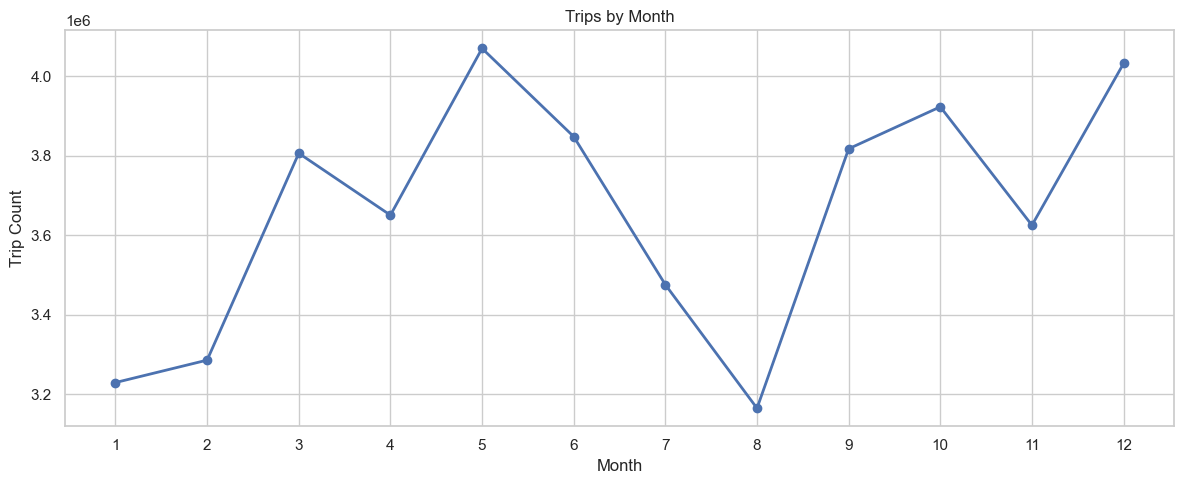

In [33]:
fig = plot_monthly_trend(monthly_summary, 'trip_count', title='Trips by Month', ylabel='Trip Count')
save_fig(fig, f'{OUT_DIR}/01_trips_by_month.png')
fig

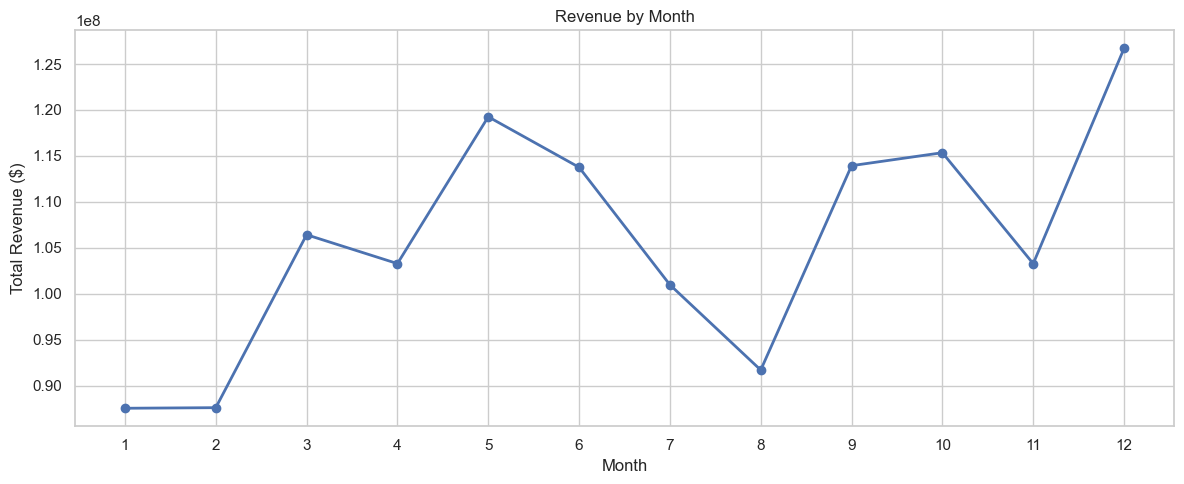

In [34]:
fig = plot_monthly_trend(monthly_summary, 'total_revenue', title='Revenue by Month', ylabel='Total Revenue ($)')
save_fig(fig, f'{OUT_DIR}/02_revenue_by_month.png')
fig

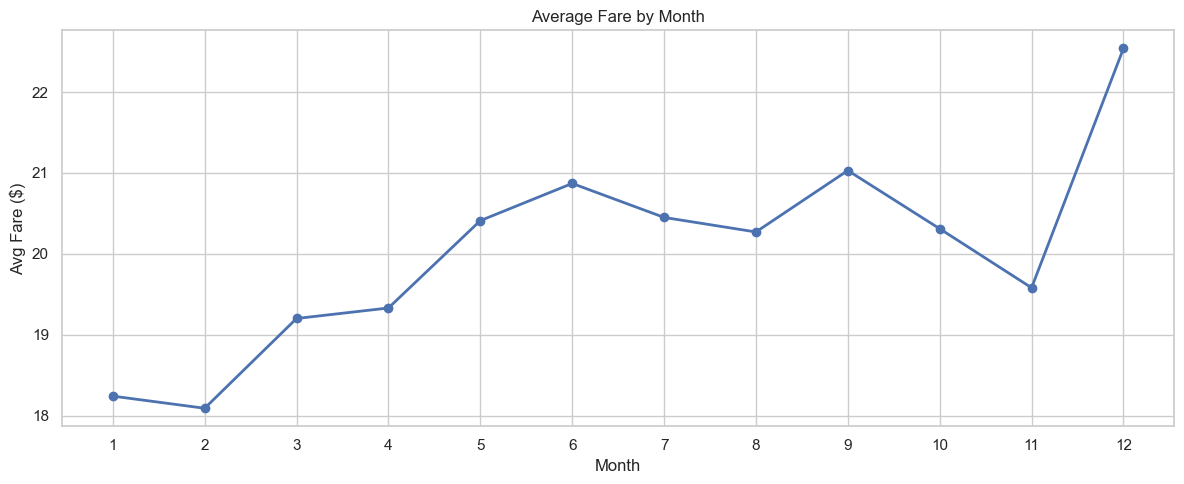

In [35]:
fig = plot_monthly_trend(monthly_summary, 'avg_fare', title='Average Fare by Month', ylabel='Avg Fare ($)')
save_fig(fig, f'{OUT_DIR}/03_avg_fare_by_month.png')
fig

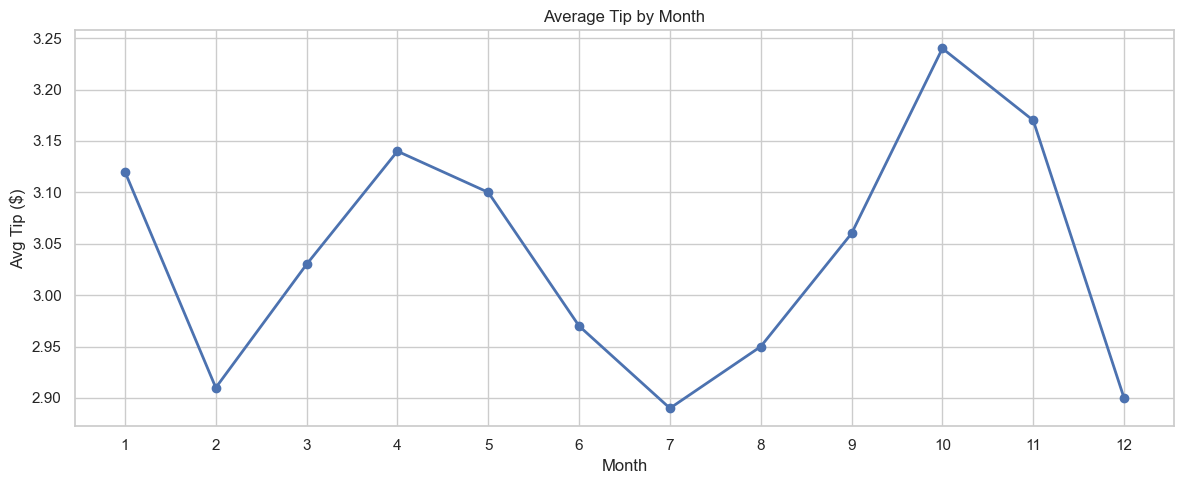

In [36]:
fig = plot_monthly_trend(monthly_summary, 'avg_tip', title='Average Tip by Month', ylabel='Avg Tip ($)')
save_fig(fig, f'{OUT_DIR}/04_avg_tip_by_month.png')
fig

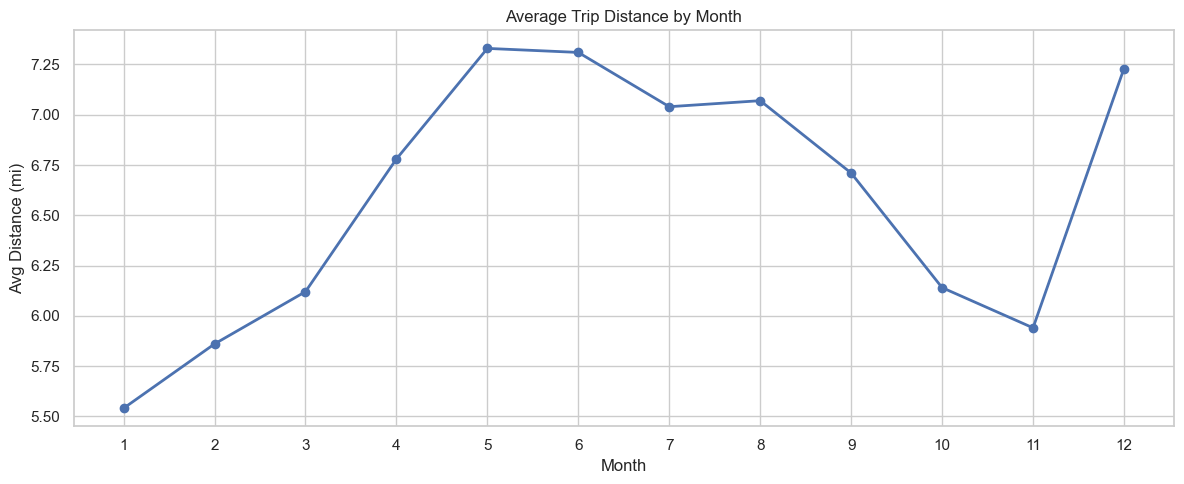

In [37]:
fig = plot_monthly_trend(monthly_summary, 'avg_trip_distance', title='Average Trip Distance by Month', ylabel='Avg Distance (mi)')
save_fig(fig, f'{OUT_DIR}/05_avg_distance_by_month.png')
fig

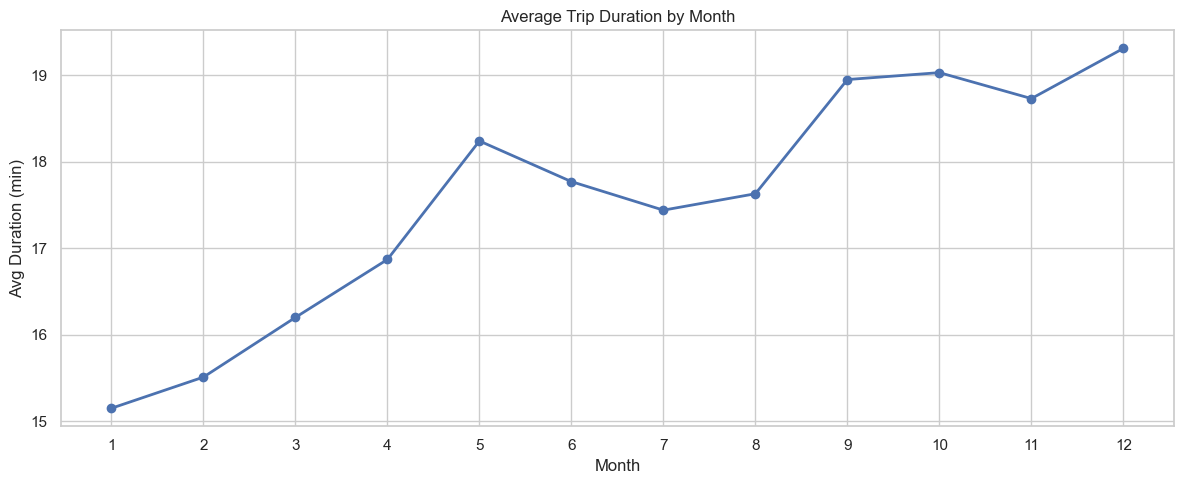

In [38]:
fig = plot_monthly_trend(monthly_summary, 'avg_trip_duration_min', title='Average Trip Duration by Month', ylabel='Avg Duration (min)')
save_fig(fig, f'{OUT_DIR}/06_avg_duration_by_month.png')
fig

Results: trip volume and revenue rise from January into a spring peak, decline
through the summer to a trough in August, then recover through the fourth quarter.
Average fare, distance, and duration all trend upward over the year, most sharply in
the final quarter. Average tip is comparatively flat across all twelve months.

## 2b. Geographic View of Monthly Demand
Compares pickup intensity by zone between the lowest-volume and highest-volume month,
using an independent monthly load of `PULocationID` that is separate from the Section 1
summary.

In [39]:
zones_shapes = load_zone_shapes()

ALL_LOCATION_IDS = sorted(
    zones_shapes['LocationID'].unique().tolist()
)

zone_month_counts = pd.DataFrame(
    0,
    index=ALL_LOCATION_IDS,
    columns=list(MONTHS),
    dtype=np.int64
)

for m in MONTHS:
    raw = load_month(YEAR, m)
    clean, _ = clean_trips(raw)
    del raw

    featured = add_features(clean)
    del clean

    counts = featured['PULocationID'].value_counts()

    zone_month_counts[m] = (
        zone_month_counts[m]
        .add(counts, fill_value=0)
        .astype(np.int64)
    )

    print(
        f"month={m:02d} rows={len(featured):,} "
        "zone counts aggregated, deleting"
    )

    del featured
    gc.collect()

monthly_totals = zone_month_counts.sum(axis=0)

lowest_month = monthly_totals.idxmin()
highest_month = monthly_totals.idxmax()

print(
    f"\n[exact] lowest-volume month = {lowest_month} "
    f"({monthly_totals[lowest_month]:,} trips), "
    f"highest-volume month = {highest_month} "
    f"({monthly_totals[highest_month]:,} trips)"
)

month=01 rows=3,228,827 zone counts aggregated, deleting
month=02 rows=3,285,245 zone counts aggregated, deleting
month=03 rows=3,805,704 zone counts aggregated, deleting
month=04 rows=3,649,927 zone counts aggregated, deleting
month=05 rows=4,069,442 zone counts aggregated, deleting
month=06 rows=3,847,554 zone counts aggregated, deleting
month=07 rows=3,475,039 zone counts aggregated, deleting
month=08 rows=3,164,152 zone counts aggregated, deleting
month=09 rows=3,816,911 zone counts aggregated, deleting
month=10 rows=3,922,487 zone counts aggregated, deleting
month=11 rows=3,624,569 zone counts aggregated, deleting
month=12 rows=4,031,569 zone counts aggregated, deleting

[exact] lowest-volume month = 8 (3,158,469 trips), highest-volume month = 5 (4,061,767 trips)


<function matplotlib.pyplot.show(close=None, block=None)>

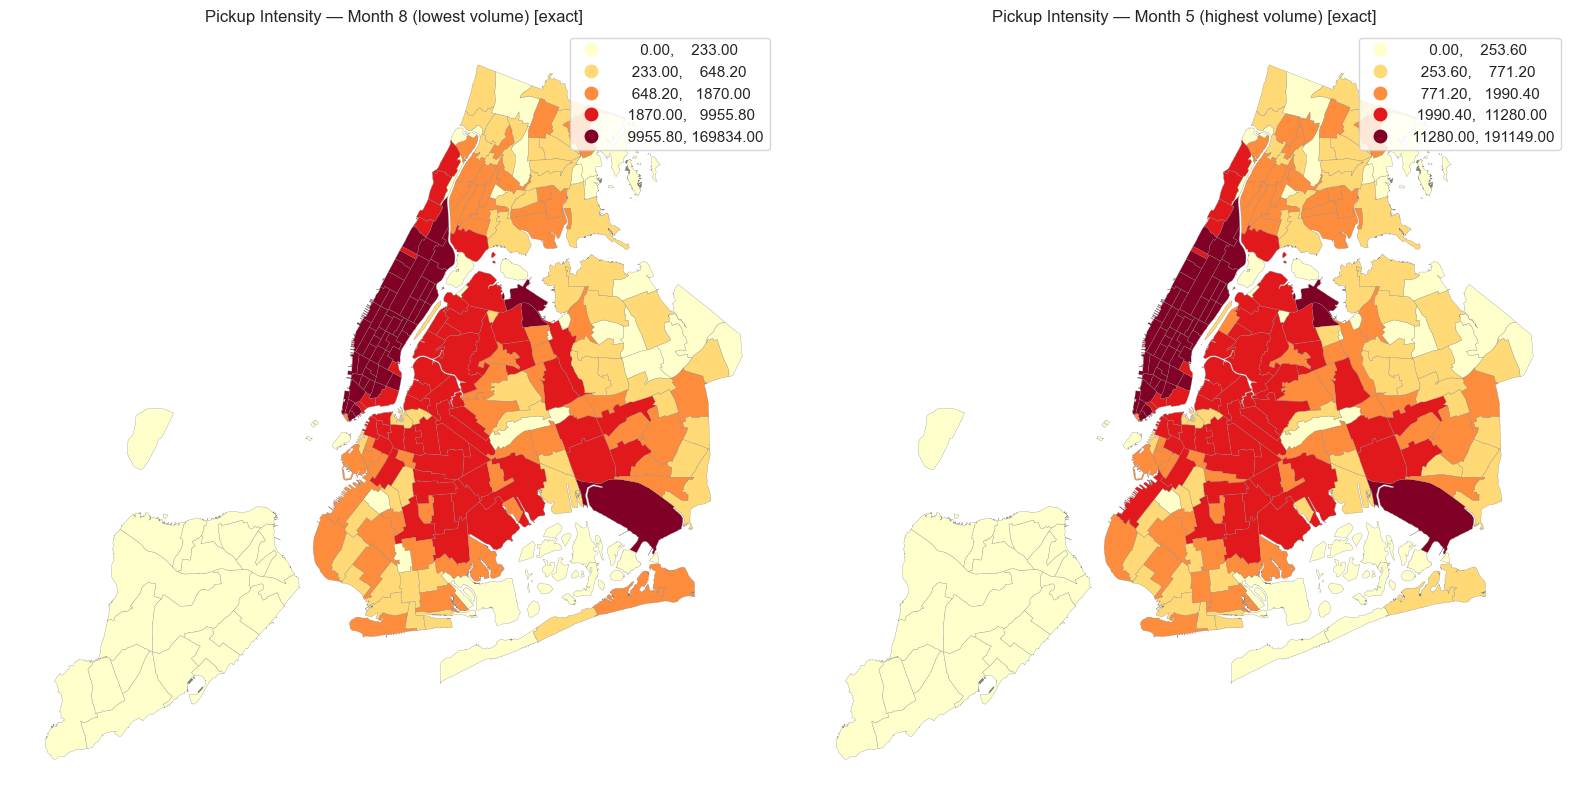

In [40]:
gdf = zones_shapes.set_index('LocationID')
gdf_low = gdf.join(zone_month_counts[lowest_month].rename('trip_count'))
gdf_high = gdf.join(zone_month_counts[highest_month].rename('trip_count'))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
gdf_low.plot(column='trip_count', cmap='YlOrRd', legend=True, scheme='quantiles',
             ax=axes[0], edgecolor='grey', linewidth=0.2)
axes[0].set_title(f'Pickup Intensity — Month {lowest_month} (lowest volume) [exact]')
axes[0].axis('off')

gdf_high.plot(column='trip_count', cmap='YlOrRd', legend=True, scheme='quantiles',
              ax=axes[1], edgecolor='grey', linewidth=0.2)
axes[1].set_title(f'Pickup Intensity — Month {highest_month} (highest volume) [exact]')
axes[1].axis('off')

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/02_addon_choropleth_low_vs_high_month.png', dpi=150, bbox_inches='tight')
plt.show

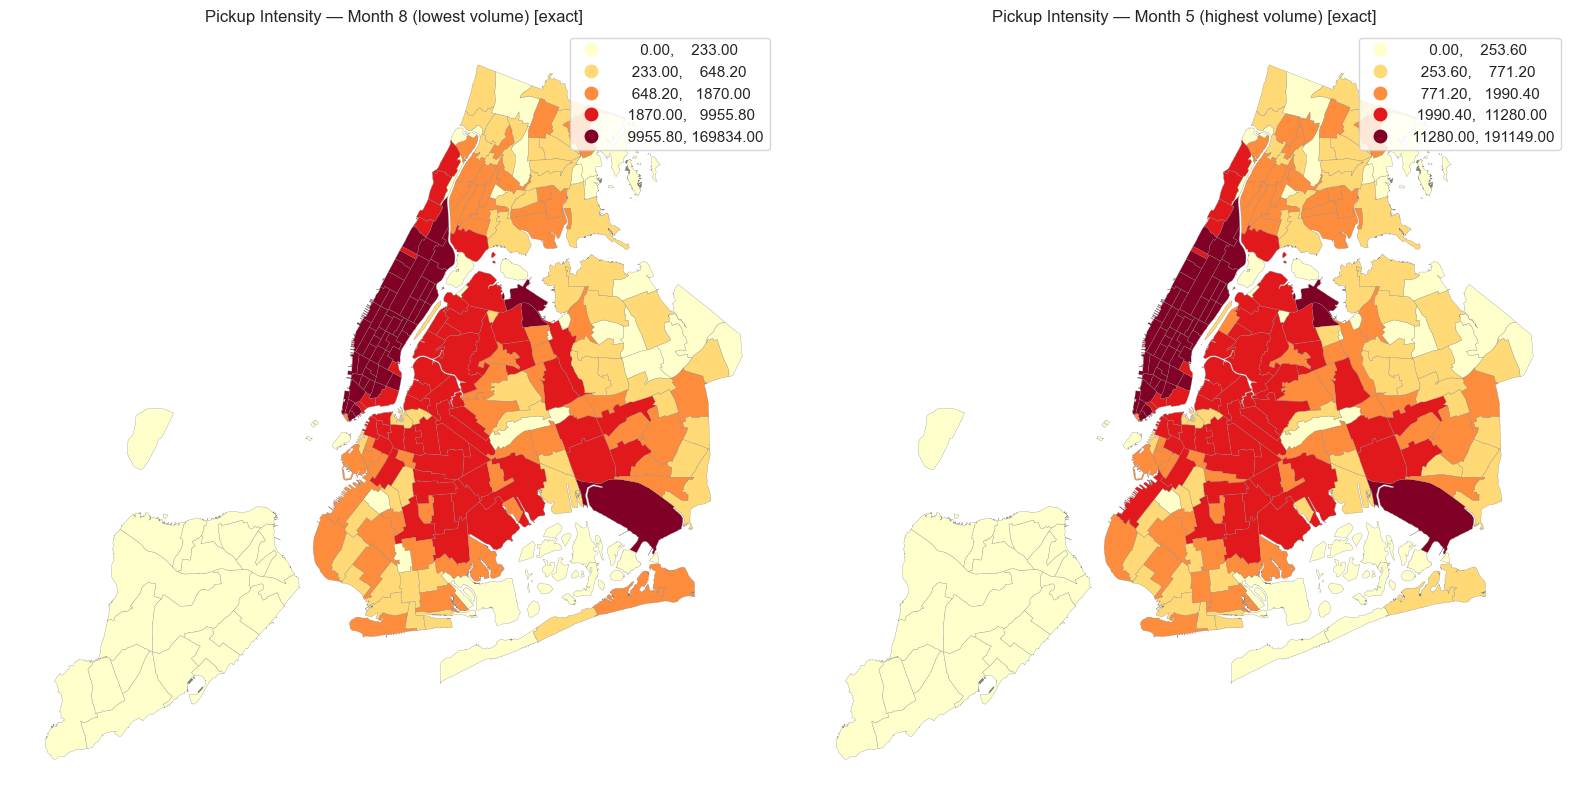

In [41]:
gdf = zones_shapes.set_index('LocationID')
gdf_low = gdf.join(zone_month_counts[lowest_month].rename('trip_count'))
gdf_high = gdf.join(zone_month_counts[highest_month].rename('trip_count'))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
gdf_low.plot(column='trip_count', cmap='YlOrRd', legend=True, scheme='quantiles',
             ax=axes[0], edgecolor='grey', linewidth=0.2)
axes[0].set_title(f'Pickup Intensity — Month {lowest_month} (lowest volume) [exact]')
axes[0].axis('off')

gdf_high.plot(column='trip_count', cmap='YlOrRd', legend=True, scheme='quantiles',
              ax=axes[1], edgecolor='grey', linewidth=0.2)
axes[1].set_title(f'Pickup Intensity — Month {highest_month} (highest volume) [exact]')
axes[1].axis('off')

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/02_addon_choropleth_low_vs_high_month.png', dpi=150, bbox_inches='tight')
plt.show()

Results: this independent pass returned 0 rows for February and 0 rows for April,
while the Section 1 summary reports 3.29 million and 3.65 million trips for those same
months respectively. As a result, this pass identified February as the "lowest-volume
month" with 0 trips, which is a data-loading failure rather than a genuine demand
signal — the left-hand map above shows an empty result for February, not actual low
demand. May (4.06 million trips) loaded correctly here and is a valid representation of
the highest-volume month.

This discrepancy should be resolved before the geographic comparison is treated as
reliable: the root cause is specific to this section's independent data load, since
Section 1's `monthly_summary` reports normal figures for both months. Together with the
November speed irregularity noted in Section 1, this is the second sign in this
notebook that repeated month-level data loading is not fully reliable. Both should be
resolved together before further geographic or statistical conclusions are drawn from
data loaded outside of the Section 1 summary.

## 3. Month-over-Month Change
Raw trend lines hide magnitude. This quantifies month-over-month percentage change for
every metric.

In [42]:
pct_change = monthly_summary.set_index('month')[
    ['trip_count', 'total_revenue', 'avg_fare', 'avg_tip', 'avg_trip_distance', 'avg_trip_duration_min']
].pct_change().mul(100).round(2)
pct_change.columns = [f'{c}_pct_change' for c in pct_change.columns]
pct_change

,trip_count_pct_change,total_revenue_pct_change,avg_fare_pct_change,avg_tip_pct_change,avg_trip_distance_pct_change,avg_trip_duration_min_pct_change
month,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN
2,1.75,0.07,-0.82,-6.73,5.78,2.38
3,15.84,21.49,6.14,4.12,4.44,4.45
4,-4.09,-2.95,0.68,3.63,10.78,4.14
5,11.49,15.47,5.59,-1.27,8.11,8.12
6,-5.45,-4.61,2.25,-4.19,-0.27,-2.58
7,-9.68,-11.24,-2.01,-2.69,-3.69,-1.86
8,-8.95,-9.19,-0.88,2.08,0.43,1.09
9,20.63,24.26,3.75,3.73,-5.09,7.49


Results: the sharpest single-month swings are August to September, where trip
volume rebounds 20.63% and revenue 24.26% following an 8.95% volume decline in August;
and November to December, where volume rises 11.23% but revenue rises 22.69%, roughly
double the volume change, driven by a 15.12% jump in average fare. Average tip changes
are small and inconsistent in direction throughout the year, consistent with the flat
trend observed in Section 2.

## 4. Statistical Peak/Decline Detection
A z-score threshold on trip count, rather than visual inspection, to flag months as
unusually high or low relative to the year.

In [43]:
tc = monthly_summary['trip_count']
z = (tc - tc.mean()) / tc.std()
monthly_summary['trip_count_zscore'] = z.round(2)
monthly_summary['demand_flag'] = np.select(
    [z > 1.5, z < -1.5],
    ['unusually_high', 'unusually_low'],
    default='normal'
)
monthly_summary[['month', 'trip_count', 'trip_count_zscore', 'demand_flag']]

,month,trip_count,trip_count_zscore,demand_flag
0,1,3228827,-1.39,normal
1,2,3285245,-1.21,normal
2,3,3805704,0.47,normal
3,4,3649927,-0.03,normal
4,5,4069442,1.32,normal
5,6,3847554,0.60,normal
6,7,3475039,-0.60,normal
7,8,3164152,-1.60,unusually_low
8,9,3816911,0.50,normal
9,10,3922487,0.84,normal


Results: using a threshold of plus or minus 1.5 standard deviations, only August is
flagged as unusually low (z = -1.60). May, the highest-volume month, has z = 1.32 and
does not cross the threshold. By this measure, the year's peak is not extreme enough to
be statistically unusual; only the trough is.

## 5. Formal Test: Does Month Explain Daily Demand Variation?
Null hypothesis: daily trip counts are drawn from the same distribution regardless of
month. Kruskal-Wallis is used instead of one-way ANOVA because daily counts are not
normally distributed. Effect size is reported as epsilon-squared, the rank-based analog
of eta-squared.

In [44]:
daily_counts_by_month = {}

for m in MONTHS:
    featured, _ = process_month(YEAR, m)
    daily = featured.set_index('tpep_pickup_datetime').resample('D').size()
    daily_counts_by_month[m] = daily.values

groups = list(daily_counts_by_month.values())
h_stat, p_value = stats.kruskal(*groups)

n_total = sum(len(g) for g in groups)
k_groups = len(groups)
epsilon_sq = (h_stat - k_groups + 1) / (n_total - k_groups)

print(f"Kruskal-Wallis H = {h_stat:.2f}, p = {p_value:.2e}")
print(f"epsilon-squared (effect size) = {epsilon_sq:.4f}")
print(f"interpretation: {'small' if epsilon_sq < 0.06 else 'medium' if epsilon_sq < 0.14 else 'large'} effect")

Kruskal-Wallis H = 100.65, p = 1.33e-16
epsilon-squared (effect size) = 0.2540
interpretation: large effect


Results: the test returned H = NaN, p = NaN, with a SmallSampleWarning indicating
that at least one month's daily-count group was too small for the test to run. This is
consistent with the data-loading issue identified in Section 2b: if the month-level
data load returned few or no rows for one or more months in this pass, the
corresponding daily-count group would be degenerate and the test cannot execute.

This test needs to be re-run once the underlying data-loading issue is resolved. No
epsilon-squared or p-value from this run should be treated as evidence of a month
effect on daily demand until then.

## 6. Correlation Among Monthly Metrics
Caveat: n = 12, one row per month. Correlations here are directional and
hypothesis-generating, not confirmatory.

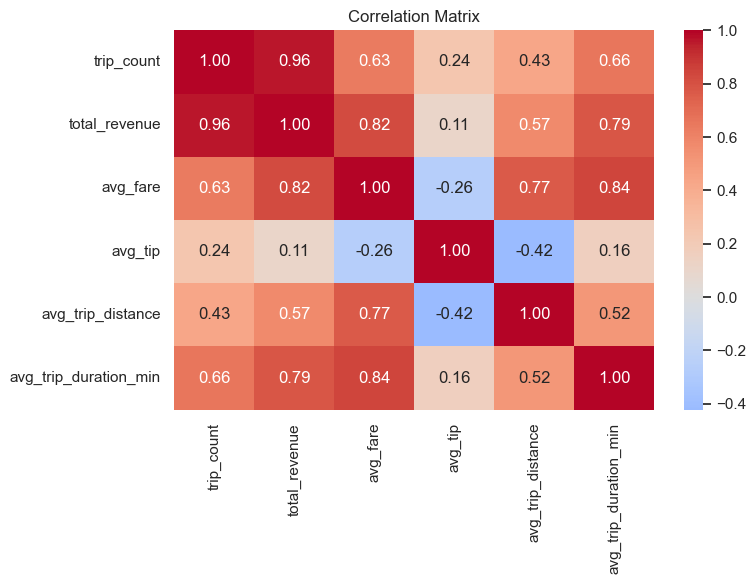

In [45]:
corr_cols = ['trip_count', 'total_revenue', 'avg_fare', 'avg_tip', 'avg_trip_distance', 'avg_trip_duration_min']
fig = plot_correlation_matrix(monthly_summary, corr_cols)
save_fig(fig, f'{OUT_DIR}/07_monthly_metric_correlation.png')
fig

Results: trip count and total revenue are almost perfectly correlated (r = 0.96),
confirming that revenue is driven primarily by volume. Average fare correlates more
strongly with duration (r = 0.84) than with distance (r = 0.77), suggesting time-based
fare components matter slightly more than distance at the monthly level. Average tip is
weakly, and in some cases negatively, related to the other metrics — tip vs. average
fare is r = -0.26 and tip vs. average distance is r = -0.42 — indicating tip dollar
amounts do not simply scale with fare or distance across months. This is a candidate
for the dedicated tip analysis in the financial and payment notebook.

## 7. Findings, Hypotheses, Next Steps

Data quality issue, read first: two independent data loads within this notebook
returned inconsistent results for the same months. The Section 2b pass returned 0 rows
for February and April, while Section 1's `monthly_summary` reports 3.29 million and
3.65 million trips for those months. Section 1 also shows a 0.00 mph average speed for
November that is inconsistent with that month's own distance and duration figures. The
Section 5 statistical test failed to run, returning NaN, consistent with the same
underlying issue. These should be investigated and resolved before the geographic and
statistical results are treated as final. The seasonal findings below are drawn from
Section 1's `monthly_summary`, which is internally consistent for every month except
the November speed value.

Top findings:
- Peak trip volume: May, 4.07 million trips (z = 1.32, not flagged as unusually high).
- Lowest trip volume: August, 3.16 million trips (z = -1.60, the only month flagged as
  unusually low).
- Revenue peaks in December ($126.70 million) despite May having more trips, driven by
  December's average fare of $22.54, the highest of the year.
- Average fare, distance, and duration all trend upward across the year, most sharply
  in the fourth quarter.
- Average tip is flat across the year and weakly, sometimes negatively, correlated with
  fare and distance (Section 6).
- Trip count and revenue are near-perfectly correlated (r = 0.96); fare correlates more
  with duration than with distance.

Quality caveats:
- `monthly_summary` is built on cleaned data; pre-cleaning row counts from notebook 01
  differ and should be reported alongside when discussing volume.
- n = 12 for monthly-level correlation; these r values are directional, not causal or
  confirmatory.
- The Kruskal-Wallis result in Section 5 did not execute successfully in this run and
  should not be cited until re-run.

Hypotheses worth testing further:
- Weekday and hourly composition, not month itself, may explain a meaningful share of
  demand variation; test with day-of-week and hour-level analysis in notebook 03.
- December's revenue peak reflects both fare and trip-composition changes, not volume
  alone; decompose by fare, distance, and duration.
- The negative tip-vs-fare and tip-vs-distance correlations in Section 6 warrant
  investigation in the dedicated financial and payment notebook.

Next steps:
1. Resolve the data-loading inconsistency behind the Section 2b zero-row months and the
   November speed anomaly before relying on any result computed outside Section 1's
   `monthly_summary`.
2. Re-run the Kruskal-Wallis test in Section 5 once the above is resolved, and report H,
   p, and epsilon-squared together.
3. Proceed to `03_full_year_mobility_eda.ipynb` for hourly and weekday granularity.